In [1]:
import operator
from IPython.display import display, Image

from langchain_openai import ChatOpenAI
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt


In [2]:
class State(TypedDict):
    nlist : Annotated[List[str], operator.add]
    

In [3]:
def node_a(state:State)->State:
    print(f"Adding 'A' to {state['nlist']}")
    return State(nlist = ['A'])

def node_b(state:State)->State:
    print(f"Adding 'B' to {state['nlist']}")
    return State(nlist = ['B'])

def node_bb(state:State)->State:
    print(f"Adding 'BB' to {state['nlist']}")
    return State(nlist = ['BB'])

def node_c(state:State)->State:
    print(f"Adding 'C' to {state['nlist']}")
    return State(nlist = ['C'])

def node_cc(state:State)->State:
    print(f"Adding 'CC' to {state['nlist']}")
    return State(nlist = ['CC'])

def node_d(state:State)->State:
    print(f"Adding 'D' to {state['nlist']}")
    return State(nlist = ['D'])


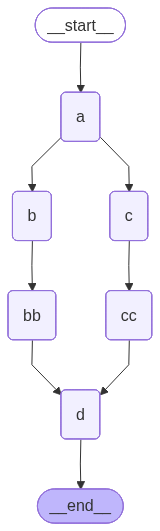

In [4]:
# build the graph
builder = StateGraph(State)

# Add nodes
builder.add_node('a', node_a)
builder.add_node('b', node_b)
builder.add_node('bb', node_bb)
builder.add_node('c', node_c)
builder.add_node('cc', node_cc)
builder.add_node('d', node_d)

# Add edges
builder.add_edge(START, 'a')
builder.add_edge('a', 'b')
builder.add_edge('a', 'c')
builder.add_edge('b', 'bb')
builder.add_edge('c', 'cc')
builder.add_edge('bb', 'd')
builder.add_edge('cc', 'd')
builder.add_edge('d', END)

# compile
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
initial_state = State(
    nlist=['hello, this is a start message']
)
graph.invoke(initial_state)

Adding 'A' to ['hello, this is a start message']
Adding 'B' to ['hello, this is a start message', 'A']
Adding 'C' to ['hello, this is a start message', 'A']
Adding 'BB' to ['hello, this is a start message', 'A', 'B', 'C']
Adding 'CC' to ['hello, this is a start message', 'A', 'B', 'C']
Adding 'D' to ['hello, this is a start message', 'A', 'B', 'C', 'BB', 'CC']


{'nlist': ['hello, this is a start message', 'A', 'B', 'C', 'BB', 'CC', 'D']}

### Conditional edges
